# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [2]:
from typing import Iterable, List

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [3]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [5]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        # Q(w,X,y)=1/ℓ||Xw−y||^2
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        scalar_vector = np.dot(X, w)
        raz = scalar_vector - y
        square = np.square(raz)
        loss = np.mean(square)
        return loss

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # ∇wQ(w,X,y)=2/ℓ *XT(Xw−y)
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        scalar_vector = np.dot(X, w)
        raz = scalar_vector - y
        Xt = X.T
        num_rows = X.shape[0]
        grad = 2 * np.dot(Xt, raz) / num_rows
        return grad

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [6]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [7]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w_pred = w_init
    trajectory = [w_pred]
    for t in range(n_iterations):
      w = w_pred - lr * loss.calc_grad(X, y, w_pred)
      trajectory.append(w)
      w_pred = w
    return np.array(trajectory)

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [8]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))
print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [9]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.8670644395649493


In [10]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

GD trajectory for lr = 0.0005


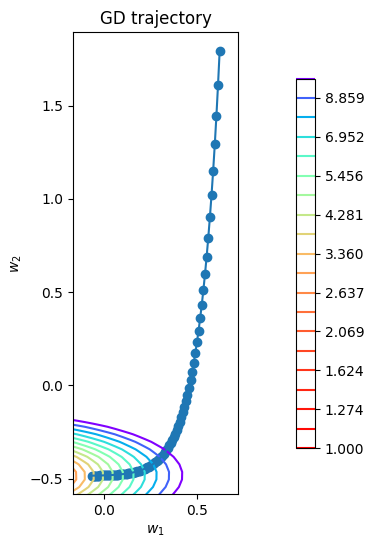

GD trajectory for lr = 0.001


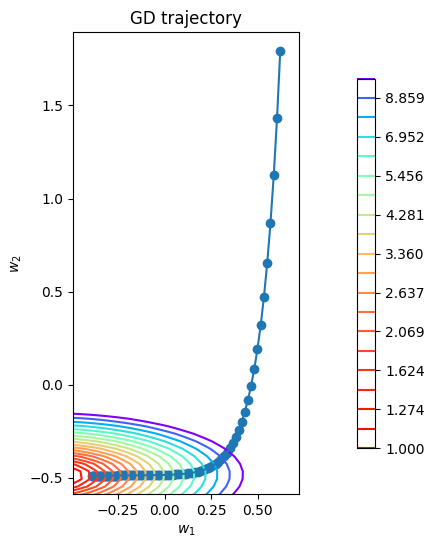

GD trajectory for lr = 0.005


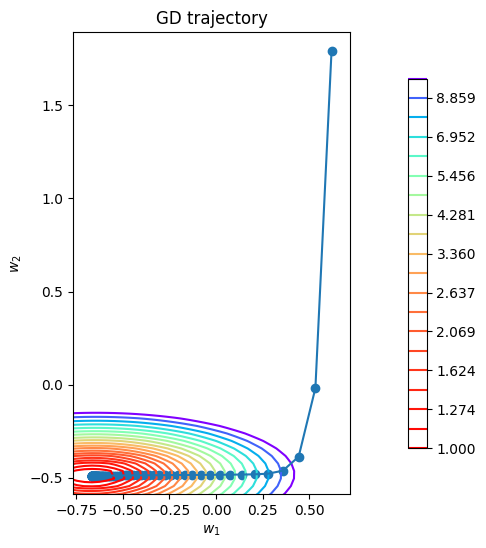

GD trajectory for lr = 0.008


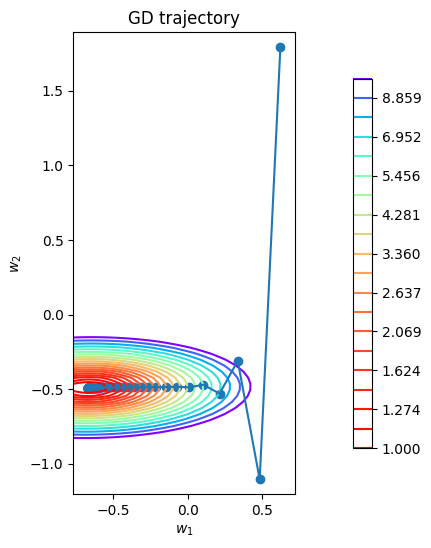

GD trajectory for lr = 0.01


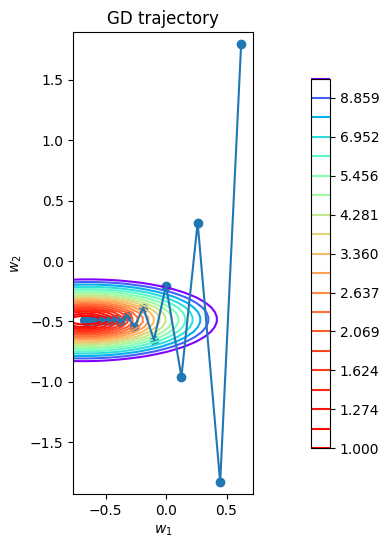

GD trajectory for lr = 0.012


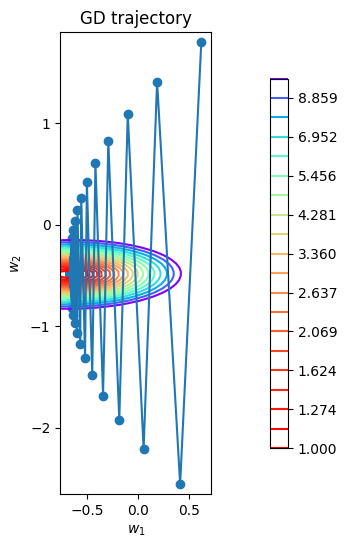

In [11]:
steps = [0.0005, 0.001, 0.005, 0.008, 0.01, 0.012]
for step in steps:
    print(f'GD trajectory for lr = {step}')
    w_list = gradient_descent(w_init, X, y, loss, step, 100)
    ax = plot_gd(w_list, X, y, loss)

**Ответ:**

Слишком маленький шаг (например, 0.0005) с большой вероятностью позволит найти минимум функции. Из-за маленьких шагов градиентный спуск последовательно идет в нужную сторону и его траектория получается ровной, точно направленной к минимуму. Однако на больших данных градиентный спуск с маленьким шагом будет работать долго, поскольку ему потребуется очень много итераций. Это не совсем хорошо, так как обучение может затянуться.

Слишком большой шаг (например, 0,012) приводит к тому, что траектория градиента становится хаотичной, и в окрестностях минимума градиент начинает сильно колебаться. Из-за большого шага есть вероятность, что градиентный спуск проскочит минимум и не придет туда вовсе. Это может привести к большей ошибке модели.



Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [12]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w_pred = w_init
    trajectory = [w_pred]
    for t in range(n_iterations):
      batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      batch = X[batch_indices]
      y_batch = y[batch_indices]
      w = w_pred - lr * loss.calc_grad(batch, y_batch, w_pred)
      w_pred = w
      trajectory.append(w)
    return np.array(trajectory)

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

Stochastic gd trajectory for lr = 0.0005 and batch_size = 12


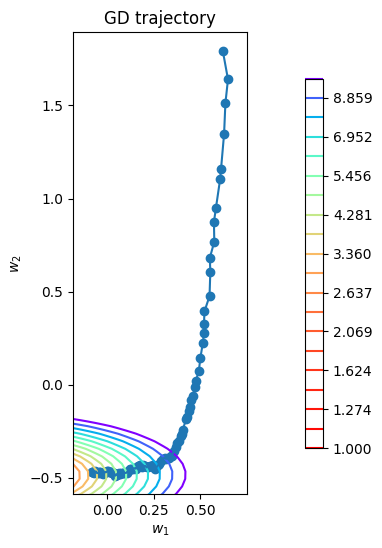

Stochastic gd trajectory for lr = 0.001 and batch_size = 250


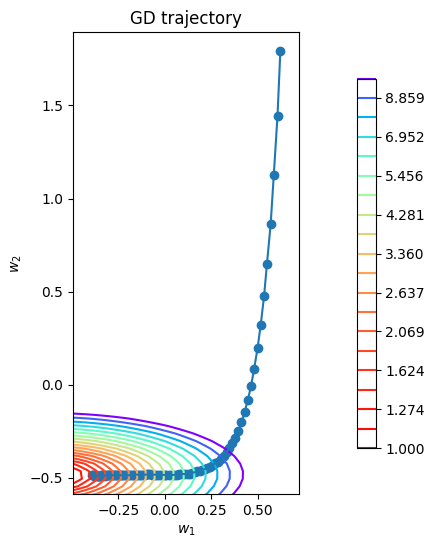

Stochastic gd trajectory for lr = 0.005 and batch_size = 70


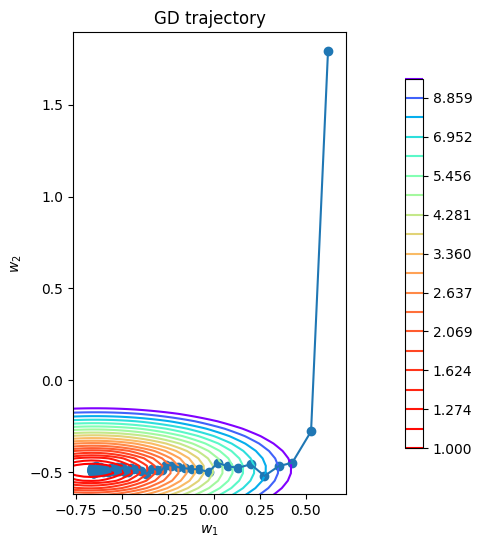

Stochastic gd trajectory for lr = 0.008 and batch_size = 180


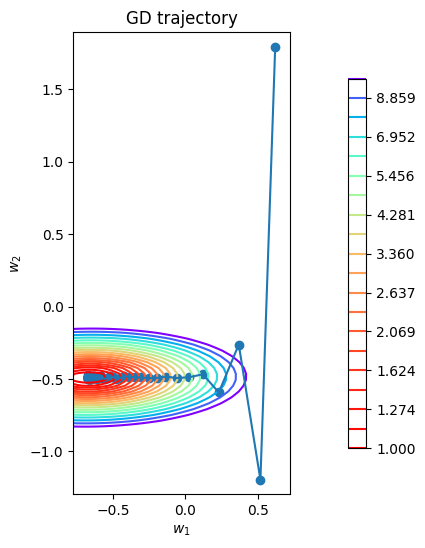

Stochastic gd trajectory for lr = 0.01 and batch_size = 60


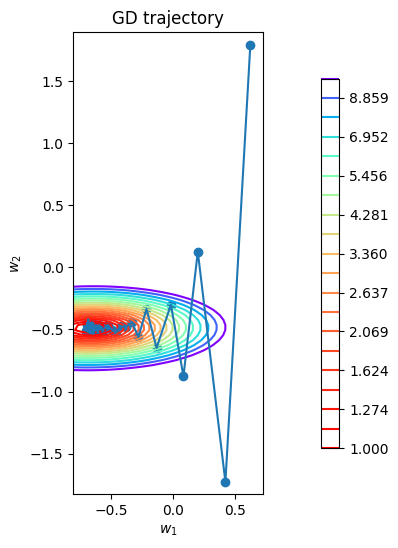

Stochastic gd trajectory for lr = 0.012 and batch_size = 250


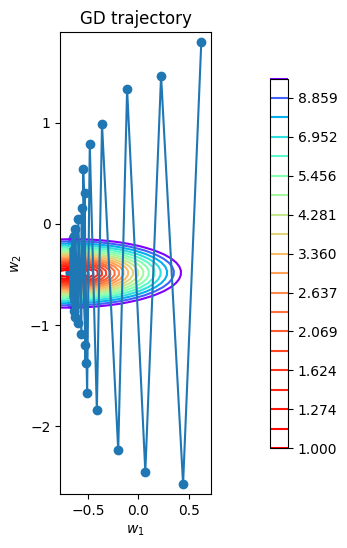

In [13]:
steps = [0.0005, 0.001, 0.005, 0.008, 0.01, 0.012]
batch_sizes = [12, 250, 70, 180, 60, 250]
for i in range(6):
  print(f'Stochastic gd trajectory for lr = {steps[i]} and batch_size = {batch_sizes[i]}')
  w_list = stochastic_gradient_descent(w_init, X, y, loss, steps[i], batch_sizes[i], 100)
  plot_gd(w_list, X, y, loss)

**Ответ:**

При маленькой выборке(12) траектория стохастического градиентного спуска становится менее стабильной по сравнению с обычным спуском, так как оценка градиента на маленькой выборке получается менее точной.

Чем больше выборка, тем градиентный спуск стабильнее (например, для lr = 0.001 и batch_size = 250).

Шаг в свою очередь влияет на стохастический градиентный спуск примерно также, как на обычный

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [14]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w_pred = w_init
    trajectory = [w_pred]
    s0 = 1
    for t in range(n_iterations):
      batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      batch = X[batch_indices]
      y_batch = y[batch_indices]
      s = lr * (s0/ (s0 + t)) ** p
      w = w_pred - s * loss.calc_grad(batch, y_batch, w_pred)
      w_pred = w
      trajectory.append(w)
    return np.array(trajectory)

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

SGD trajectory for p = 0.01


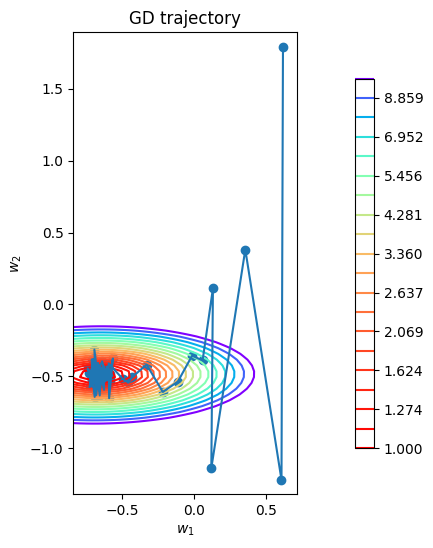

SGD trajectory for p = 0.012


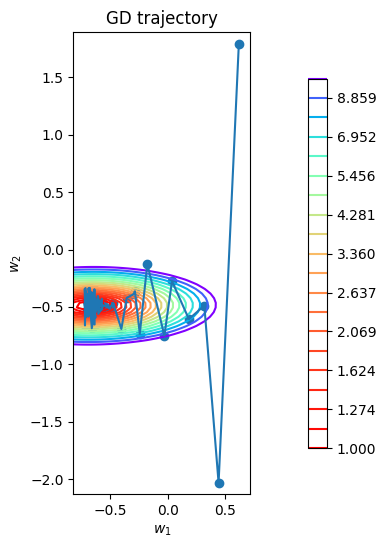

SGD trajectory for p = 0.05


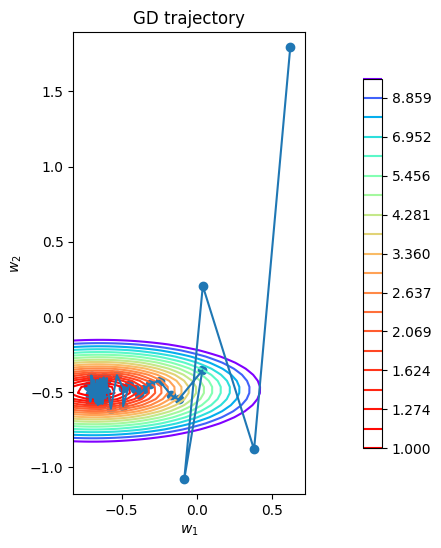

SGD trajectory for p = 0.0734


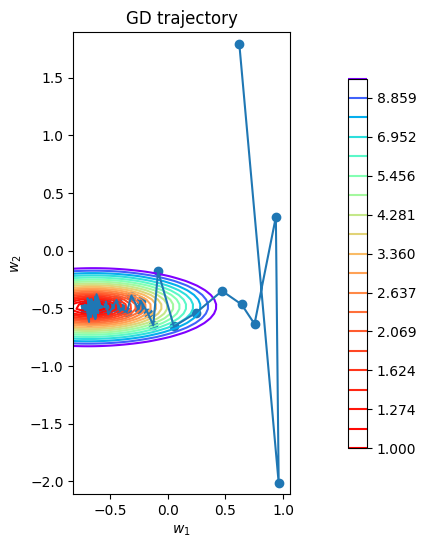

SGD trajectory for p = 0.09


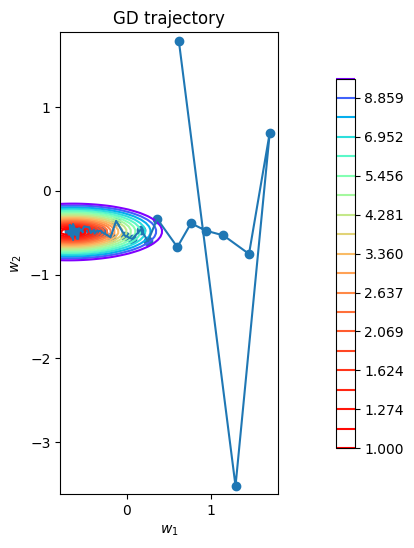

SGD trajectory for p = 1


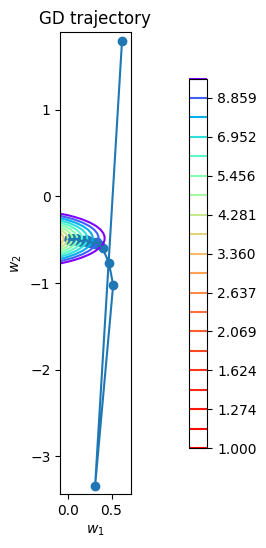

In [15]:
p_list = [0.01, 0.012, 0.05, 0.0734, 0.09, 1]
for p in p_list:
  print(f'SGD trajectory for p = {p}')
  w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, p, 100)
  plot_gd(w_list, X, y, loss)

**Ответ:**

При маленьком знаачении p длина шага с каждой итерацией изменяется незначительно и, подходя к минимуму, все еще имеет сильные колебания. Это может привести к тому, что градиентный спуск все-таки проскочит минимум.

При большом p длина шага на каждой итерации быстро уменьшается. Чем ближе спуск к минимуму, тем меньше становится длина шага. Это позволяет более точно определить минимальное значение функции.

Видно, что при p = 0.9 или p = 1 стохастический градиентный спуск быстро находит окрестности минимума и длина шага становится достаточно маленькой, чтобы более точно обнаружить минимум.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

In [16]:
trajectory_sgd = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 1)
trajectory_gd = gradient_descent(w_init, X, y, loss, 0.01)
loss_gd = []
loss_sgd = []
for w in trajectory_gd:
  loss_gd.append(loss.calc_loss(X, y, w))
loss_gd_list = np.array(loss_gd)
for w in trajectory_sgd:
  loss_sgd.append(loss.calc_loss(X, y, w))
loss_sgd_list = np.array(loss_sgd)

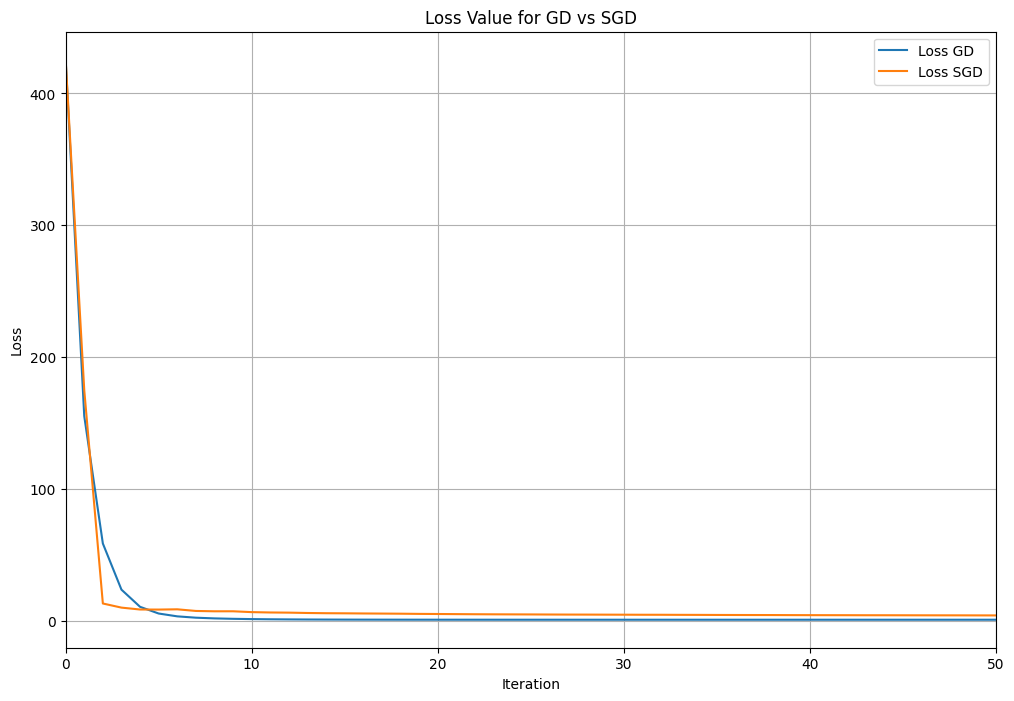

In [17]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(loss_gd_list.shape[0]), loss_gd_list, label='Loss GD')
plt.plot(np.arange(loss_sgd_list.shape[0]), loss_sgd_list, label='Loss SGD')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Value for GD vs SGD')
plt.legend()
plt.xlim(0,50)
plt.grid(True)
plt.show()


**Ответ:**

По графику видно, что обычный градиентный спуск приходит к минимуму где-то на 8-10 итерации, в то время как стохастическому градиентному спуску требуется около 40- 50 итераций. Однако на каждой итерации SGD вычисляется вразы быстрее, чем обычный GD, поэтому можно сказать, что он лучше подходит для поиска минимума.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [18]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.01) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        num_cols = X.shape[1]
        w_init = np.random.randn(num_cols)
        trajectory_gd = gradient_descent(w_init, X, y, self.loss, self.lr)
        self.w = trajectory_gd[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        a = np.dot(X, self.w)
        return a


Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [19]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [29]:
import pandas as pd

X_raw = pd.read_csv(
    "https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw05_gd/cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[25].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [30]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

**Для начала заполним пропуски в данных:**

Пропуски в категориальных признаках заменим наиболее часто встречающимся значением - модой.

Пропуски в числовых признаках будем заменять медианой, так как среднее значение из-за выбросов может быть не совсем корректным.

In [31]:
categorial_columns = X_raw.select_dtypes(include=['object'])
missing_cat_replacer = SimpleImputer(strategy='most_frequent')
x_raw_no_mis_cat  = pd.DataFrame(
    data = missing_cat_replacer.fit_transform(categorial_columns),
    columns = categorial_columns.columns,
    index=categorial_columns.index
)

In [32]:
numeric_columns = X_raw.select_dtypes(exclude=['object'])
missing_numbers_replacer = SimpleImputer(strategy = 'median')
x_raw_no_mis_num  = pd.DataFrame(
    data = missing_numbers_replacer.fit_transform(numeric_columns),
    columns = numeric_columns.columns,
    index=numeric_columns.index
)

In [33]:
X_raw = pd.concat([x_raw_no_mis_num, x_raw_no_mis_cat], axis = 1)

**Удалим пропуски из целевой переменной, заполнив их медианой:**

In [34]:
y.isnull().sum()

np.int64(4)

In [38]:
mediana = y.median()
y = y.fillna(mediana)

**Далее закодируем категориальные признаки:**

In [39]:
categorial_columns = X_raw[X_raw.columns[X_raw.dtypes == 'object']].columns
for column in categorial_columns:
    unique = X_raw[column].unique()
    print(f"Признак {column}: {unique}")

Признак 3: ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
Признак 4: ['gas' 'diesel']
Признак 5: ['std' 'turbo']
Признак 6: ['two' 'four']
Признак 7: ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
Признак 8: ['rwd' 'fwd' '4wd']
Признак 9: ['front' 'rear']
Признак 15: ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
Признак 16: ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
Признак 18: ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


Всего категориальных признаков в датасете 10.
Признаки 6 и 16 включают в себя значения, которые имеют порядок, поэтому их можно закодировать с помощью OrdinalEncoder.
Остальные признаки не содержат порядка. Закодируем их с помощью OneHotEncoder.

In [40]:
ordinal_encoder = OrdinalEncoder(categories=[['two', 'four']])
X_raw[6] = ordinal_encoder.fit_transform(X_raw[[6]])

In [41]:
ordinal_encoder = OrdinalEncoder(categories=[['four', 'six', 'five', 'three', 'twelve', 'two', 'eight']])
X_raw[16] = ordinal_encoder.fit_transform(X_raw[[16]])

In [42]:
X_raw

,1,2,10,11,12,13,14,17,19,20,...,3,4,5,6,7,8,9,15,16,18
0,3.0,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,0.0,convertible,rwd,front,dohc,0.0,mpfi
1,3.0,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,0.0,convertible,rwd,front,dohc,0.0,mpfi
2,1.0,115.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,alfa-romero,gas,std,0.0,hatchback,rwd,front,ohcv,1.0,mpfi
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,audi,gas,std,1.0,sedan,fwd,front,ohc,0.0,mpfi
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,audi,gas,std,1.0,sedan,4wd,front,ohc,2.0,mpfi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.0,95.0,109.1,188.8,68.9,55.5,2952.0,141.0,3.78,3.15,...,volvo,gas,std,1.0,sedan,rwd,front,ohc,0.0,mpfi
201,-1.0,95.0,109.1,188.8,68.8,55.5,3049.0,141.0,3.78,3.15,...,volvo,gas,turbo,1.0,sedan,rwd,front,ohc,0.0,mpfi
202,-1.0,95.0,109.1,188.8,68.9,55.5,3012.0,173.0,3.58,2.87,...,volvo,gas,std,1.0,sedan,rwd,front,ohcv,1.0,mpfi
203,-1.0,95.0,109.1,188.8,68.9,55.5,3217.0,145.0,3.01,3.40,...,volvo,diesel,turbo,1.0,sedan,rwd,front,ohc,1.0,idi


In [43]:
one_hot_encoder = OneHotEncoder(drop="first")
X_raw.columns = X_raw.columns.astype(str)
categorial_columns = X_raw.select_dtypes(include=['object']).columns.tolist()
numeric_columns = X_raw.select_dtypes(exclude=['object'])
X_cat = pd.DataFrame(
    data = one_hot_encoder.fit_transform(X_raw[categorial_columns]).toarray(),
    columns = one_hot_encoder.get_feature_names_out(categorial_columns)
)

X_raw = pd.concat([numeric_columns, X_cat], axis = 1)

In [44]:
X_raw

,1,2,10,11,12,13,14,17,19,20,...,15_ohcf,15_ohcv,15_rotor,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi,18_spfi
0,3.0,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3.0,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,115.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.0,95.0,109.1,188.8,68.9,55.5,2952.0,141.0,3.78,3.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
201,-1.0,95.0,109.1,188.8,68.8,55.5,3049.0,141.0,3.78,3.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
202,-1.0,95.0,109.1,188.8,68.9,55.5,3012.0,173.0,3.58,2.87,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
203,-1.0,95.0,109.1,188.8,68.9,55.5,3217.0,145.0,3.01,3.40,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


**Далее разделим датасет на обучающую и тестовую выборки:**

In [45]:
np.random.seed(35)
x_train, x_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=35)

**Теперь нормализируем числовые признаки:**

In [46]:
normalizer = StandardScaler()
normalizer.fit(x_train)
x_train = pd.DataFrame(data=normalizer.transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(data=normalizer.transform(x_test), columns=x_test.columns)

In [47]:
x_train.head(5)

,1,2,10,11,12,13,14,17,19,20,...,15_ohcf,15_ohcv,15_rotor,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi,18_spfi
0,-0.703941,2.106648,0.444005,0.269904,-0.499858,0.241386,0.343370,1.023011,-0.037358,-0.225389,...,-0.288675,-0.226871,-0.169638,-0.710819,-0.146385,-0.354943,-0.083918,1.126872,-0.190347,0.0
1,0.959919,0.439380,-0.043463,0.220145,-0.111382,-0.768687,0.032772,0.554548,1.059398,0.761914,...,-0.288675,-0.226871,-0.169638,-0.710819,-0.146385,-0.354943,-0.083918,1.126872,-0.190347,0.0
2,-0.703941,2.106648,0.444005,0.269904,-0.499858,0.241386,0.450810,1.023011,-0.037358,-0.225389,...,-0.288675,-0.226871,-0.169638,-0.710819,-0.146385,-0.354943,-0.083918,1.126872,-0.190347,0.0
3,0.127989,0.254128,-0.722437,-0.658928,-0.985455,-0.197777,-0.988883,-0.720712,-0.603426,0.093096,...,-0.288675,-0.226871,-0.169638,1.406829,-0.146385,-0.354943,-0.083918,-0.887412,-0.190347,0.0
4,0.127989,1.180388,1.244846,1.588514,2.705077,0.856213,0.605133,0.294291,-0.461909,0.443429,...,-0.288675,-0.226871,-0.169638,-0.710819,-0.146385,-0.354943,-0.083918,1.126872,-0.190347,0.0


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [48]:
lin_reg = LinearRegression(MSELoss())
lin_reg.fit(x_train, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [49]:
from sklearn.metrics import mean_squared_error

y_train_pred = lin_reg.predict(x_train)
y_test_pred = lin_reg.predict(x_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"MSE на train: {mse_train:.0f}")
print(f"MSE на test: {mse_test:.0f}")

MSE на train: 2836912
MSE на test: 6513382


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [50]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        raz = np.dot(X, w) - y
        square = np.square(raz)
        loss =  np.mean(square) + self.coef * np.sum(w[:-1] ** 2)
        return loss


    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        raz = np.dot(X, w) - y
        num_rows = X.shape[0]
        grad = 2 * np.dot(X.T, raz) / num_rows
        reg = 2 * self.coef * w
        grad_with_reg = grad + reg
        grad_with_reg[-1] = grad[-1]
        return grad_with_reg


Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [51]:
lin_reg1 = LinearRegression(MSEL2Loss(0.105))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [52]:
lin_reg1.fit(x_train, y_train)
y_train_pred = lin_reg1.predict(x_train)
y_test_pred = lin_reg1.predict(x_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"MSE на train: {mse_train:.0f}")
print(f"MSE на test: {mse_test:.0f}")

MSE на train: 3812172
MSE на test: 5609802


**Ответ:**

Регресия без регуляризации дала результат:

MSE на train: 2836912

MSE на test: 6513382

Регресия с регуляризацией дала результат:

MSE на train: 3812172

MSE на test: 5609802

На обучающей выборке при добавлении регуляризации ошибка  возросла, но на тестовой выборке удалось снизить ее практически на 1млн.руб. В данном случае линейная регрессия с регуляризацией показала лучший результат.

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [53]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        z = np.dot(X, w) - y
        f = np.where(np.abs(z) < self.eps,  0.5 * z ** 2,
            self.eps * (np.abs(z) - 0.5 * self.eps)
        )
        loss = np.mean(f)
        return loss

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        z = np.dot(X, w) - y
        f = np.where(np.abs(z) < self.eps, z, self.eps * np.sign(z))
        Xt = X.T
        grad = np.dot(Xt, f) / X.shape[0]

        return grad

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [54]:
lin_reg2 = LinearRegression(HuberLoss(30))
lin_reg2.fit(x_train, y_train)
y_train_pred = lin_reg2.predict(x_train)
y_test_pred = lin_reg2.predict(x_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"MSE на train: {mse_train:.0f}")
print(f"MSE на test: {mse_test:.0f}")

MSE на train: 4948320
MSE на test: 5425935


**Ответ:**

Регресия без регуляризации дала результат:

MSE на train: 2836912

MSE на test: 6513382

Регресия с HuberLoss дала результат:

MSE на train: 4948320

MSE на test: 5425935

На обучающей выборке при добавлении регуляризации ошибка  возросла, но на тестовой выборке удалось снизить ее практически на 2млн.руб. В данном случае линейная регрессия с HuberLoss показала самый лучший результат по сравнению с обычной регрессией и регрессией с регуляризацией.




**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

<a href="https://imgbb.com/"><img src="https://i.ibb.co/zWgP3L0R/image.jpg" alt="image" border="0"></a>

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [ ]:
# -- YOUR CODE HERE -- ʕ•ᴥ•ʔ